# 🔬 Breast Cancer Classification
End-to-end preprocessing pipeline: loading, exploration, outlier handling, scaling, and tensor conversion.

## 1. Load Dataset
Load the breast cancer dataset from sklearn and assign features `X` and labels `y`.

In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [10]:
print(data)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [11]:
X = data.data
y = data.target 

df = pd.DataFrame(X,columns=data.feature_names)
df['target'] = y



## 2. Exploratory Data Analysis (EDA)

### 2.1 Dataset Summary
Inspect the number of samples, features, and class distribution.

In [12]:

# Dataset Summary
print("=" * 45)
print("         DATASET SUMMARY")
print("=" * 45)

print(f"\n📊 Number of Samples   : {X.shape[0]}")
print(f"🔢 Number of Features  : {X.shape[1]}")

# Class Distribution
print("\n📌 Class Distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    class_name = data.target_names[label]
    percentage = (count / len(y)) * 100
    print(f"   - {class_name.capitalize()} (class {label}): {count} samples ({percentage:.1f}%)")

print("=" * 45)


         DATASET SUMMARY

📊 Number of Samples   : 569
🔢 Number of Features  : 30

📌 Class Distribution:
   - Malignant (class 0): 212 samples (37.3%)
   - Benign (class 1): 357 samples (62.7%)


### 2.2 Class Distribution
Visualize the balance between malignant and benign classes.

/tmp/ipykernel_39499/2083116694.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


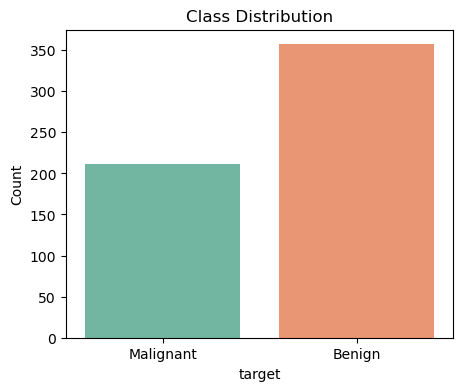

In [13]:
plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

### 2.3 Null & Duplicate Check
Verify there are no missing values or duplicate rows.

In [14]:

print("=== Null Value Check ===")
print(df.isnull().sum())  

print(f"\nTotal nulls in dataset: {df.isnull().sum().sum()}")

=== Null Value Check ===
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Total nulls in dataset: 0


In [15]:
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


### 2.4 Feature Distributions
Histograms showing the distribution shape of all 30 features.

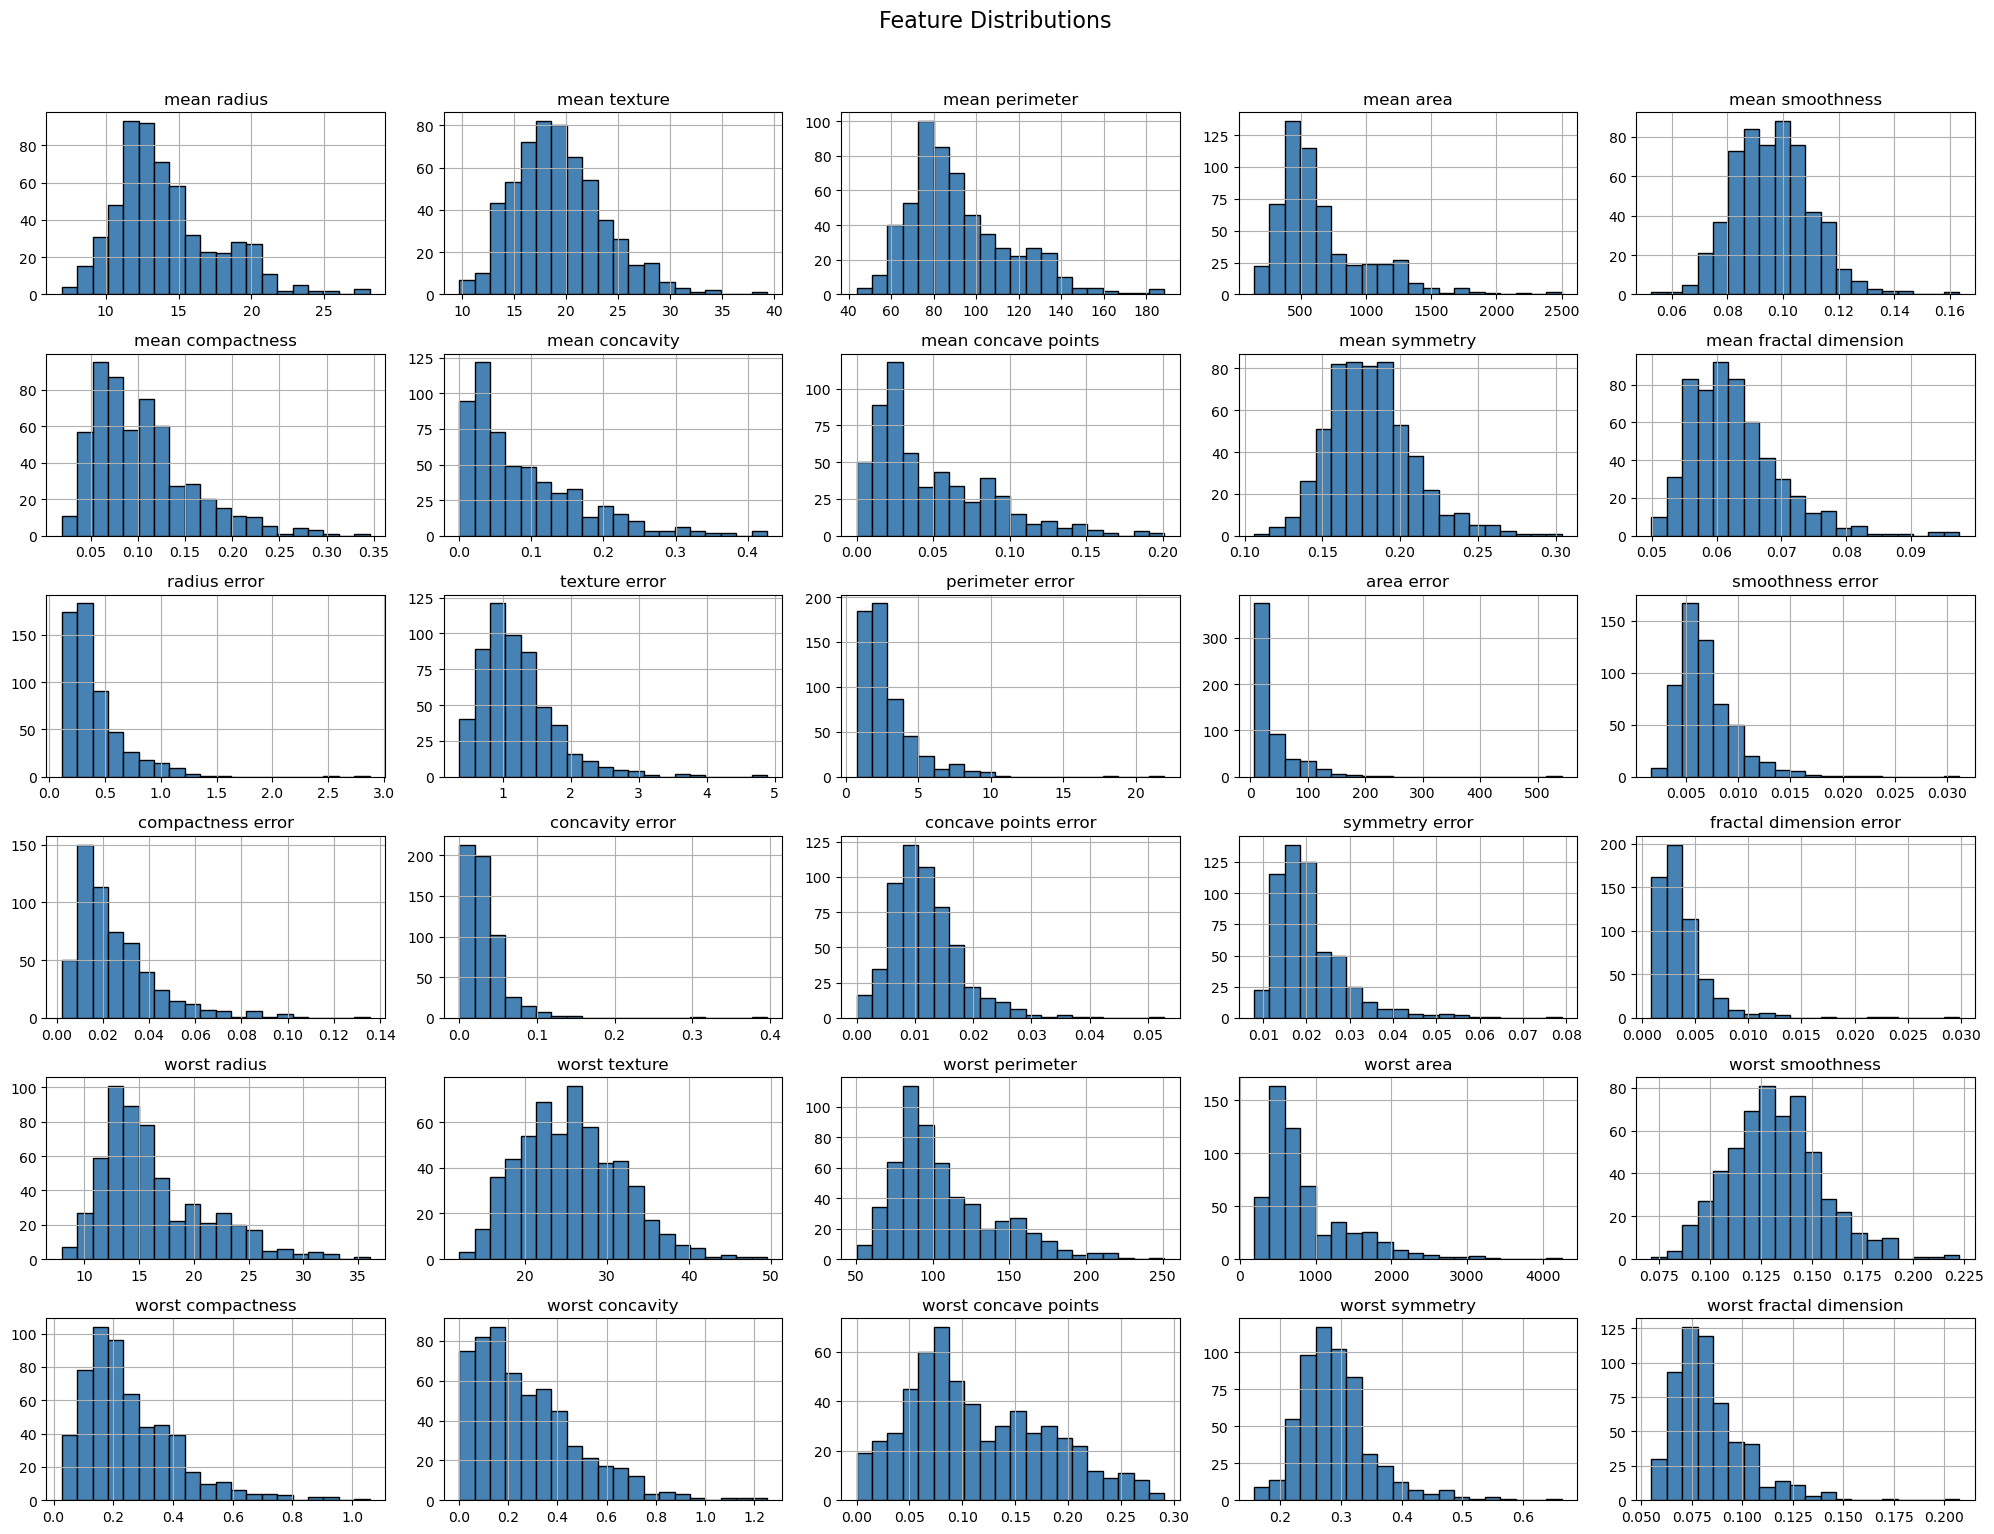

In [16]:

df.drop('target', axis=1).hist(figsize=(20, 15), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Boxplot — Feature Spread
Boxplots reveal scale differences and potential outliers across features.

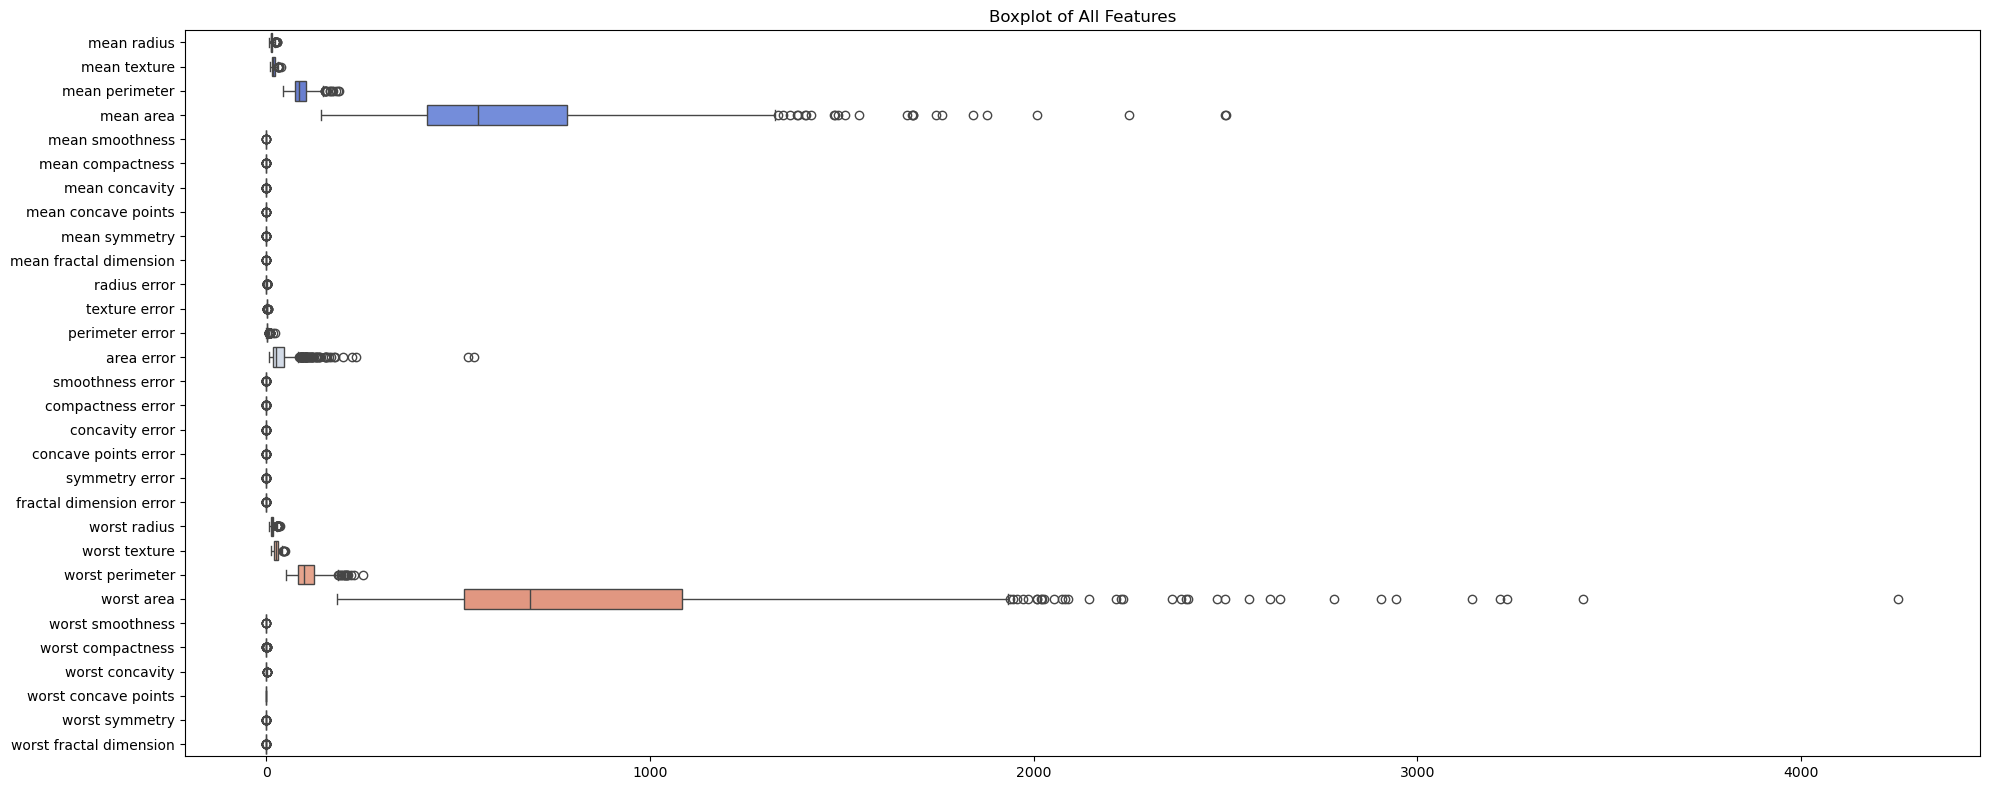

In [17]:

plt.figure(figsize=(20, 8))
sns.boxplot(data=df.drop('target', axis=1), orient='h', palette='coolwarm')
plt.title('Boxplot of All Features')
plt.tight_layout()
plt.show()

## 3. Outlier Detection & Handling

### 3.1 Detect Outliers (IQR Method)


In [18]:

cols = df.columns.drop('target')  

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR)))

print("=== Outlier Count per Feature ===")
print(outliers.sum().sort_values(ascending=False))

=== Outlier Count per Feature ===
area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
fractal dimension error    28
compactness error          28
symmetry error             27
mean area                  25
worst fractal dimension    24
worst symmetry             23
concavity error            22
texture error              20
concave points error       19
mean concavity             18
worst radius               17
worst compactness          16
mean compactness           16
mean symmetry              15
mean fractal dimension     15
worst perimeter            15
mean radius                14
mean perimeter             13
worst concavity            12
mean concave points        10
mean texture                7
worst smoothness            7
mean smoothness             6
worst texture               5
worst concave points        0
dtype: int64


### 3.2 Cap Outliers (Winsorization)


In [19]:
cols = df.columns.drop('target')

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

for col in cols:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df[col] = df[col].clip(lower=lower, upper=upper)

print("✅ Capping applied successfully")

✅ Capping applied successfully


### 3.3 Verify Capping
Re-run outlier detection to confirm all outlier counts are now 0.

In [20]:
Q1_new = df[cols].quantile(0.25)
Q3_new = df[cols].quantile(0.75)
IQR_new = Q3_new - Q1_new

outliers_after = ((df[cols] < (Q1_new - 1.5 * IQR_new)) | (df[cols] > (Q3_new + 1.5 * IQR_new)))
print("=== Outlier Count After Capping ===")
print(outliers_after.sum().sort_values(ascending=False))

=== Outlier Count After Capping ===
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


### 3.4 Visualize After Capping
Boxplots confirm outliers have been removed for all features.

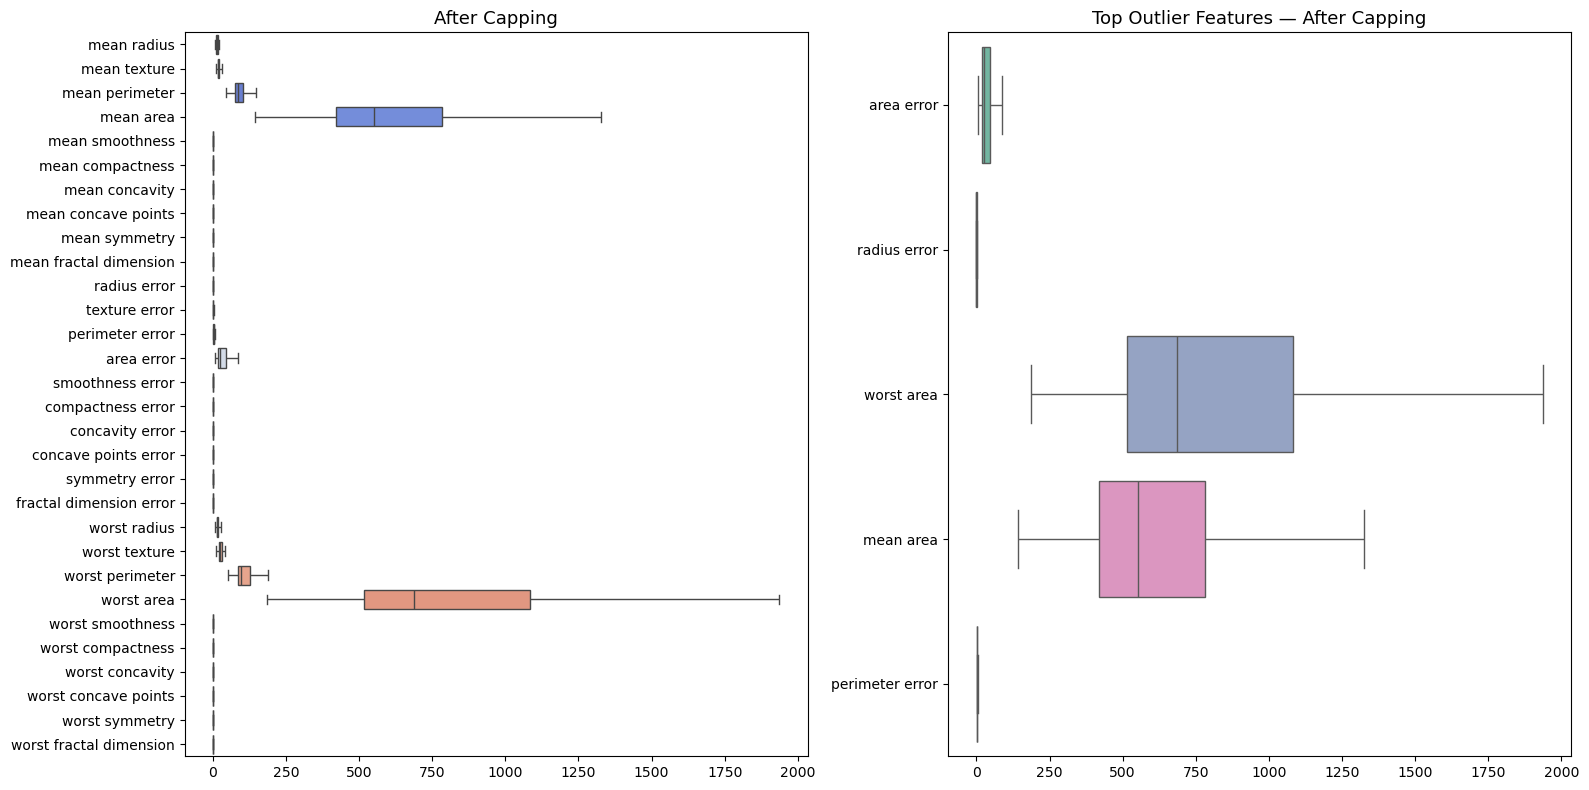

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Use original df before capping for "before" — if you saved it
sns.boxplot(data=df[cols], orient='h', ax=axes[0], palette='coolwarm')
axes[0].set_title('After Capping', fontsize=13)

# Focus on most affected features
top_features = ['area error', 'radius error', 'worst area', 'mean area', 'perimeter error']
sns.boxplot(data=df[top_features], orient='h', ax=axes[1], palette='Set2')
axes[1].set_title('Top Outlier Features — After Capping', fontsize=13)

plt.tight_layout()
plt.show()

## 4. Update X & Re-split
Pull the capped values from `df` back into `X`, then re-run the train/test split so downstream steps use clean data.

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1).values

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y, shuffle=True)

print(f"✅ X updated with capped values | Shape: {X.shape}")

✅ X updated with capped values | Shape: (569, 30)


## 5. Feature Scaling (StandardScaler)
Standardize all features to mean=0 and std=1 so no single feature dominates due to its scale.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("✅ Scaling done!")
print(f"Shape: {X_scaled.shape}")

✅ Scaling done!
Shape: (569, 30)


### 5.1 Verify Scaling
Check describe() output — mean should be ≈0 and std ≈1 for all features.

In [24]:
scaled_df = pd.DataFrame(X_scaled, columns=data.feature_names)

print("=== Before Scaling ===")
print(pd.DataFrame(X, columns=data.feature_names).describe().round(2))

print("\n=== After Scaling ===")
print(scaled_df.describe().round(2))

=== Before Scaling ===
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.06         19.25           91.54     639.77             0.10   
std           3.34          4.19           23.05     305.34             0.01   
min           6.98          9.71           43.79     143.50             0.06   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          21.90         30.24          147.49    1326.30             0.13   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
std                

### 5.2 Visualize Scaling
Boxplots before and after scaling show all features now share the same scale.

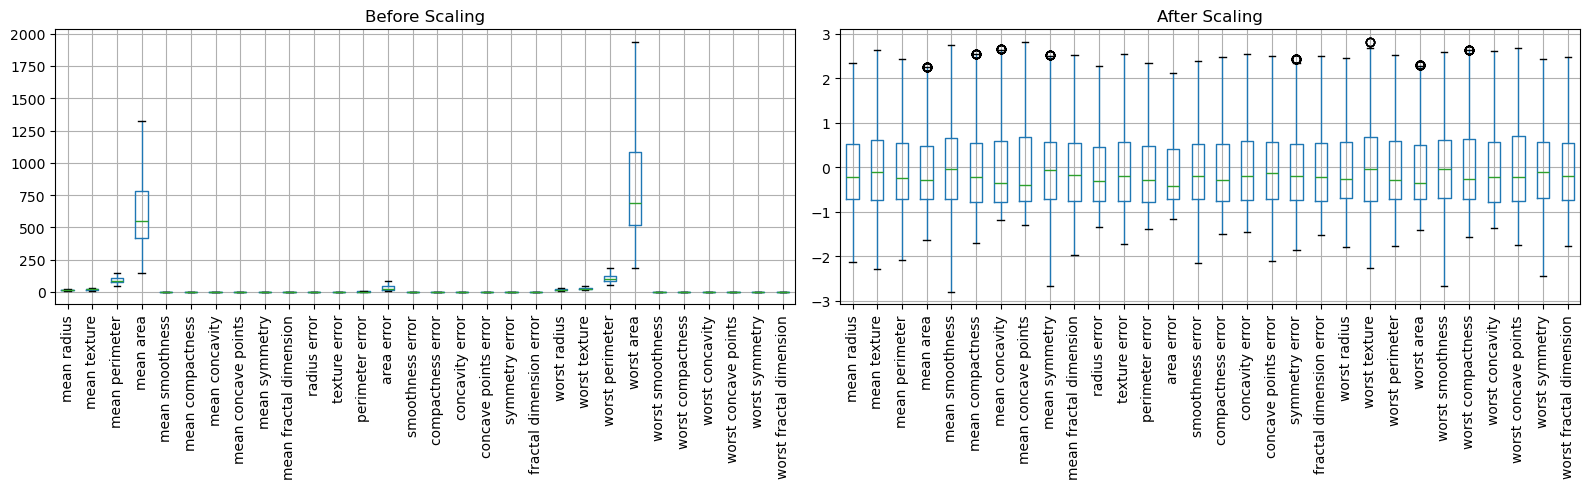

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pd.DataFrame(X, columns=data.feature_names).boxplot(ax=axes[0], rot=90)
axes[0].set_title('Before Scaling')

scaled_df.boxplot(ax=axes[1], rot=90)
axes[1].set_title('After Scaling')

plt.tight_layout()
plt.show()

## 6. Convert to PyTorch Tensors


In [26]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)


print("=== Tensor Shapes ===")
print(f"X_train : {X_train_tensor.shape}")   # (455, 30)
print(f"X_test  : {X_test_tensor.shape}")    # (114, 30)
print(f"y_train : {y_train_tensor.shape}")   # (455, 1)
print(f"y_test  : {y_test_tensor.shape}")    # (114, 1)

print("\n=== Data Types ===")
print(f"X_train dtype : {X_train_tensor.dtype}")   # float32
print(f"y_train dtype : {y_train_tensor.dtype}")   # float32

=== Tensor Shapes ===
X_train : torch.Size([455, 30])
X_test  : torch.Size([114, 30])
y_train : torch.Size([455, 1])
y_test  : torch.Size([114, 1])

=== Data Types ===
X_train dtype : torch.float32
y_train dtype : torch.float32
